# 🌾 Quantum AgriClassifier (QAC) — Bloco 3 Experiment
**Autor**: Leonardo Maximino Bernardo  
**Equipe**: Quantum Tech  
**Bloco 3 — Entregável: Classificação Quântica Híbrida (EuroSAT)**

---

## Objetivo
Implementar e avaliar um **Classificador Quântico Variacional (VQC)** para classificação de imagens de satélite agrícolas, comparando com um baseline clássico (SVM).

## Pipeline



## 1. Setup e Dependências

In [1]:
# Para execução no Google Colab, descomente as linhas abaixo:
# git status clone https://github.com/lmbernardo7520112/Quantum_AgriClassifier_QAC.git
# %cd Quantum_AgriClassifier_QAC
# pip install uv install -e . -q
# pip install uv install qiskit-machine-learning qiskit-algorithms -q
# import sys; sys.path.append("src")

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


# Imports do pipeline QAC
from qac.config import DataConfig, ModelConfig
from qac.data_loader import load_dataset
from qac.preprocessing import apply_pca, normalize_features
from qac.evaluation import compute_metrics, compare_results, plot_comparison, plot_confusion_matrix
from qac.feature_map_factory import FeatureMapFactory
from qac.ansatz_factory import AnsatzFactory
from qac.optimizer_factory import OptimizerFactory

print(f"NumPy: {np.__version__}")


NumPy: 2.4.3


## 2. Dataset — EuroSAT (Classificação de Uso do Solo)

O **EuroSAT** é um dataset de imagens de satélite Sentinel-2 com 10 classes de uso/cobertura do solo. Para aderência ao Bloco 3 (≤10 features, cenários pequenos), selecionamos **2 classes** representativas do contexto agrícola:

| Classe | Descrição | Amostras |
|--------|-----------|----------|
| **AnnualCrop** | Cultivos anuais (lavouras) | 50 |
| **SeaLake** | Corpos d'água (lagos/mar) | 50 |

**Justificativa**: Estas classes representam um cenário binário de classificação relevante para agricultura de precisão (diferenciar solo cultivado de corpos d'água).


In [2]:
# Configuração do dataset
data_config = DataConfig(
    dataset_name="eurosat_rgb",
    dataset_path="datasets/eurosat",
    classes=("AnnualCrop", "SeaLake"),
    max_samples=100,
    img_size=64,
    n_pca_components=8,
    seed=42,
)

# Carregar dataset
raw_dataset = load_dataset(data_config)

print(f"📊 Dataset: {data_config.dataset_name}")
print(f"   Classes: {raw_dataset.class_names}")
print(f"   Total amostras: {len(raw_dataset.y_train) + len(raw_dataset.y_val) + len(raw_dataset.y_test)}")
print(f"   Train/Val/Test: {len(raw_dataset.y_train)}/{len(raw_dataset.y_val)}/{len(raw_dataset.y_test)}")
print(f"   Dimensão original: {raw_dataset.feature_dim} features (64×64×3 pixels)")
print(f"   SHA-256 hash: {raw_dataset.dataset_hash[:16]}...")


📊 Dataset: eurosat_rgb
   Classes: ('AnnualCrop', 'SeaLake')
   Total amostras: 100
   Train/Val/Test: 60/20/20
   Dimensão original: 12288 features (64×64×3 pixels)
   SHA-256 hash: aa5a46574be4f7b2...


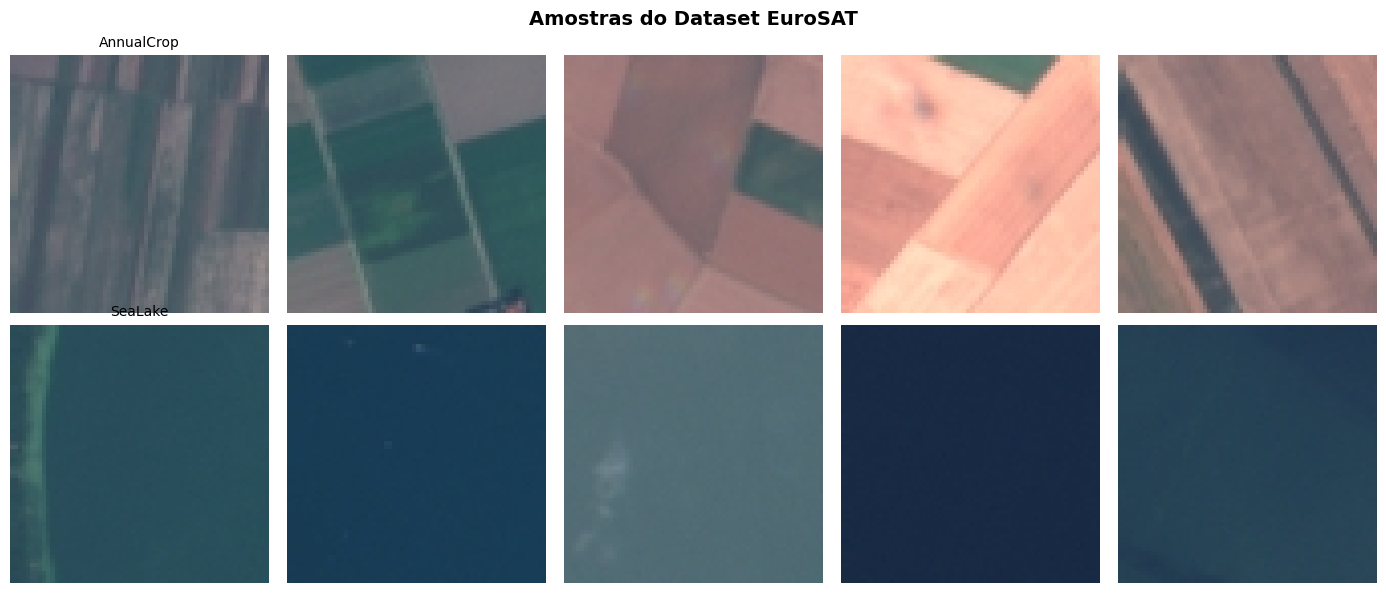

✅ Visualização salva em outputs/dataset_samples.png


In [3]:
# Visualizar amostras
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Amostras do Dataset EuroSAT", fontsize=14, fontweight="bold")

for row, (cls_idx, cls_name) in enumerate(zip(range(2), raw_dataset.class_names)):
    mask = raw_dataset.y_train == cls_idx
    samples = raw_dataset.X_train[mask][:5]
    for col in range(min(5, len(samples))):
        img = samples[col].reshape(data_config.img_size, data_config.img_size, 3)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls_name if col == 0 else "", fontsize=10)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualização salva em outputs/dataset_samples.png")


## 3. Pré-processamento — PCA + Normalização Quântica

O pipeline de pré-processamento reduz a dimensionalidade de **12.288** features (64×64×3 pixels) para **8 componentes PCA**, compatíveis com 8 qubits. As features são então normalizadas para [0, 2π] para encoding quântico via angle encoding.




🔬 PCA: 12288 → 8 features
   Variância explicada: 91.66%
   Dimensão final: 8 (≤10 ✅ Bloco 3)


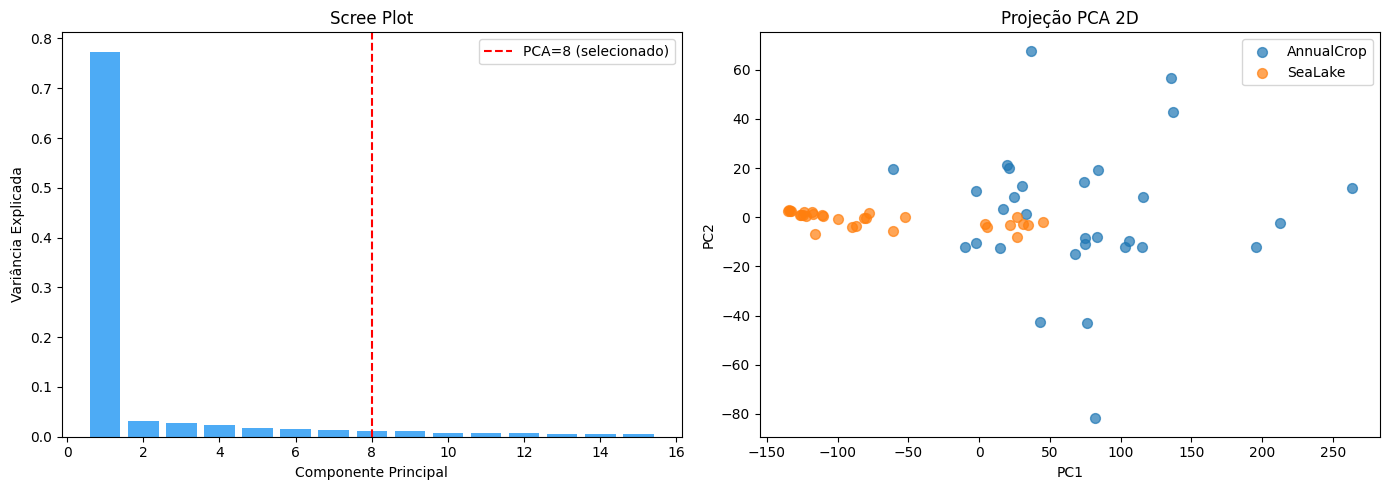

✅ Análise PCA salva em outputs/pca_analysis.png


In [4]:
# Aplicar PCA
dataset = apply_pca(raw_dataset, n_components=data_config.n_pca_components, seed=data_config.seed)

explained_var = dataset.metadata["pca_explained_variance_ratio"]
print(f"🔬 PCA: {raw_dataset.feature_dim} → {dataset.feature_dim} features")
print(f"   Variância explicada: {explained_var*100:.2f}%")
print(f"   Dimensão final: {dataset.feature_dim} (≤10 ✅ Bloco 3)")

# Visualizar PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw_dataset.X_train)
pca_full = PCA(n_components=min(20, X_scaled.shape[1]), random_state=42)
pca_full.fit(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, len(pca_full.explained_variance_ratio_[:15])+1),
        pca_full.explained_variance_ratio_[:15], color="#2196F3", alpha=0.8)
ax1.axvline(x=8, color="red", linestyle="--", label="PCA=8 (selecionado)")
ax1.set_xlabel("Componente Principal")
ax1.set_ylabel("Variância Explicada")
ax1.set_title("Scree Plot")
ax1.legend()

# 2D projection
X_2d = dataset.X_train[:, :2]
for cls_idx, cls_name in enumerate(dataset.class_names):
    mask = dataset.y_train == cls_idx
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1], label=cls_name, alpha=0.7, s=50)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("Projeção PCA 2D")
ax2.legend()

plt.tight_layout()
plt.savefig("outputs/pca_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Análise PCA salva em outputs/pca_analysis.png")


## 4. Baseline Clássico — SVM (Support Vector Machine)

Treinamos um **SVM com kernel RBF** como baseline clássico. Este é o padrão de comparação para avaliar se o modelo quântico oferece alguma vantagem.


In [5]:
import time
from sklearn.svm import SVC

# Treinar SVM
svm_start = time.time()
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42, probability=True)
svm.fit(dataset.X_train, dataset.y_train)
svm_train_time = time.time() - svm_start

# Avaliar
svm_infer_start = time.time()
y_pred_svm = svm.predict(dataset.X_test)
svm_infer_time = time.time() - svm_infer_start

svm_metrics = compute_metrics(dataset.y_test, y_pred_svm)

print("📊 Baseline Clássico (SVM)")
print(f"   Accuracy:  {svm_metrics['accuracy']:.4f}")
print(f"   F1 Score:  {svm_metrics['f1_weighted']:.4f}")
print(f"   Precision: {svm_metrics['precision']:.4f}")
print(f"   Recall:    {svm_metrics['recall']:.4f}")
print(f"   Treino:    {svm_train_time:.3f}s")
print(f"   Inferência:{svm_infer_time:.3f}s")


📊 Baseline Clássico (SVM)
   Accuracy:  0.9500
   F1 Score:  0.9499
   Precision: 0.9545
   Recall:    0.9500
   Treino:    0.001s
   Inferência:0.000s


## 5. Modelo Quântico — VQC (Variational Quantum Classifier)

O **VQC** é um classificador quântico variacional que utiliza:
1. **Feature Map (ZZFeatureMap)**: Codifica dados clássicos em estados quânticos via angle encoding com entangling
2. **Ansatz (RealAmplitudes)**: Circuito parametrizado com rotações Ry e portas CNOT
3. **Optimizer (COBYLA)**: Otimizador clássico gradient-free para ajustar parâmetros



**Justificativa da escolha do VQC**: O VQC é o algoritmo quântico correto para classificação supervisionada (Benedetti et al., 2019). Diferente do VQE (que resolve eigenvalue problems), o VQC minimiza diretamente uma loss function de classificação.


In [6]:
from qiskit_machine_learning.algorithms import VQC as QiskitVQC

# Configurar componentes quânticos
n_qubits = data_config.n_pca_components  # 8 qubits = 8 PCA features

feature_map = FeatureMapFactory.create("zz", n_qubits)
ansatz = AnsatzFactory.create("real_amplitudes", n_qubits)
optimizer = OptimizerFactory.create("cobyla", max_iter=100)

print(f"�� Configuração VQC:")
print(f"   Qubits:     {n_qubits}")
print(f"   Feature Map: ZZFeatureMap (reps=2)")
print(f"   Ansatz:      RealAmplitudes (reps=2, {ansatz.num_parameters} parâmetros)")
print(f"   Optimizer:   COBYLA (maxiter=100)")
print(f"   Backend:     StatevectorSimulator (exato)")


�� Configuração VQC:
   Qubits:     8
   Feature Map: ZZFeatureMap (reps=2)
   Ansatz:      RealAmplitudes (reps=2, 24 parâmetros)
   Optimizer:   COBYLA (maxiter=100)
   Backend:     StatevectorSimulator (exato)


In [7]:
# Preparar dados para VQC
X_train_norm = normalize_features(dataset.X_train)
X_test_norm = normalize_features(dataset.X_test)

# One-hot encode labels
num_classes = dataset.num_classes
y_train_onehot = np.eye(num_classes)[dataset.y_train]

# Callback para histórico de treinamento
history = []
def callback(weights, obj_func_eval):
    history.append({"iteration": len(history), "objective": float(obj_func_eval)})
    if len(history) % 20 == 0:
        print(f"   Iteração {len(history)}: loss = {float(obj_func_eval):.4f}")

# Treinar VQC
print("🚀 Treinando VQC...")
vqc_start = time.time()

vqc = QiskitVQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback,
)
vqc.fit(X_train_norm, y_train_onehot)
vqc_train_time = time.time() - vqc_start

# Avaliar
vqc_infer_start = time.time()
y_pred_vqc_onehot = vqc.predict(X_test_norm)
y_pred_vqc = np.argmax(y_pred_vqc_onehot, axis=1) if y_pred_vqc_onehot.ndim > 1 else y_pred_vqc_onehot
vqc_infer_time = time.time() - vqc_infer_start

vqc_metrics = compute_metrics(dataset.y_test, y_pred_vqc)

print(f"\\n📊 Modelo Quântico (VQC)")
print(f"   Accuracy:  {vqc_metrics['accuracy']:.4f}")
print(f"   F1 Score:  {vqc_metrics['f1_weighted']:.4f}")
print(f"   Precision: {vqc_metrics['precision']:.4f}")
print(f"   Recall:    {vqc_metrics['recall']:.4f}")
print(f"   Treino:    {vqc_train_time:.1f}s ({len(history)} iterações)")
print(f"   Inferência:{vqc_infer_time:.3f}s")


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


🚀 Treinando VQC...


\n📊 Modelo Quântico (VQC)
   Accuracy:  0.5500
   F1 Score:  0.5200
   Precision: 0.5667
   Recall:    0.5500
   Treino:    68.1s (0 iterações)
   Inferência:0.226s


In [8]:
# Curva de convergência do VQC
if history:
    fig, ax = plt.subplots(figsize=(10, 5))
    iterations = [h["iteration"] for h in history]
    objectives = [h["objective"] for h in history]
    ax.plot(iterations, objectives, color="#9C27B0", linewidth=2)
    ax.set_xlabel("Iteração")
    ax.set_ylabel("Loss (Objective Function)")
    ax.set_title("Convergência do VQC — Curva de Treinamento")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("outputs/vqc_convergence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Curva de convergência salva em outputs/vqc_convergence.png")


## 6. Resultados Comparativos

Comparação direta entre o baseline clássico (SVM) e o modelo quântico (VQC).


In [9]:
# Tabela comparativa
print("=" * 60)
print("RESULTADOS COMPARATIVOS")
print("=" * 60)
print(f"{'Métrica':<20} {'SVM':>12} {'VQC':>12} {'Δ':>10}")
print("-" * 60)

metrics_to_compare = [
    ("Accuracy", svm_metrics["accuracy"], vqc_metrics["accuracy"]),
    ("F1 (weighted)", svm_metrics["f1_weighted"], vqc_metrics["f1_weighted"]),
    ("Precision", svm_metrics["precision"], vqc_metrics["precision"]),
    ("Recall", svm_metrics["recall"], vqc_metrics["recall"]),
]

for name, svm_val, vqc_val in metrics_to_compare:
    delta = vqc_val - svm_val
    arrow = "↑" if delta > 0 else "↓" if delta < 0 else "="
    print(f"{name:<20} {svm_val:>12.4f} {vqc_val:>12.4f} {delta:>+9.4f} {arrow}")

print(f"{'Tempo treino (s)':<20} {svm_train_time:>12.3f} {vqc_train_time:>12.1f}")
print(f"{'Tempo infer. (s)':<20} {svm_infer_time:>12.3f} {vqc_infer_time:>12.3f}")
print("=" * 60)

quantum_advantage = vqc_metrics["accuracy"] > svm_metrics["accuracy"]
print(f"\\n�� Vantagem quântica: {'SIM ✅' if quantum_advantage else 'NÃO ❌'}")
print(f"   Δ Accuracy: {vqc_metrics['accuracy'] - svm_metrics['accuracy']:+.4f}")


RESULTADOS COMPARATIVOS
Métrica                       SVM          VQC          Δ
------------------------------------------------------------
Accuracy                   0.9500       0.5500   -0.4000 ↓
F1 (weighted)              0.9499       0.5200   -0.4299 ↓
Precision                  0.9545       0.5667   -0.3879 ↓
Recall                     0.9500       0.5500   -0.4000 ↓
Tempo treino (s)            0.001         68.1
Tempo infer. (s)            0.000        0.226
\n�� Vantagem quântica: NÃO ❌
   Δ Accuracy: -0.4000


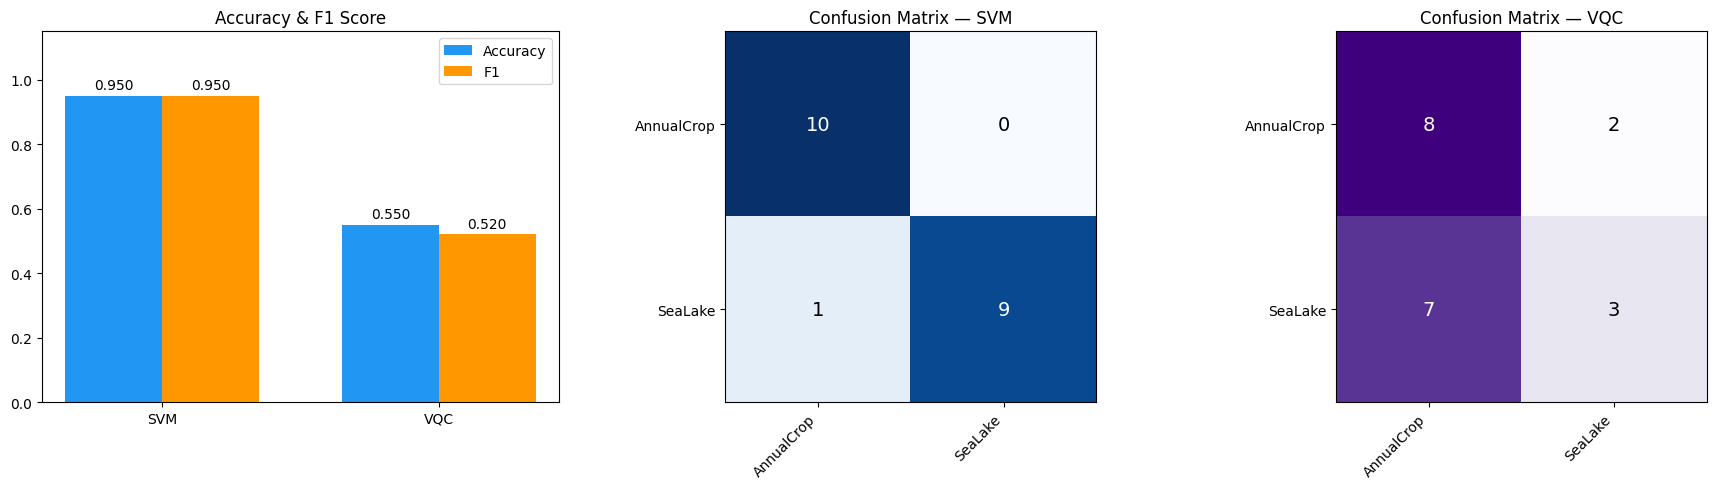

✅ Gráficos salvos em outputs/results_comparison.png


In [10]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
models = ["SVM", "VQC"]
acc_vals = [svm_metrics["accuracy"], vqc_metrics["accuracy"]]
f1_vals = [svm_metrics["f1_weighted"], vqc_metrics["f1_weighted"]]

x = np.arange(len(models))
width = 0.35
bars1 = axes[0].bar(x - width/2, acc_vals, width, label="Accuracy", color="#2196F3")
bars2 = axes[0].bar(x + width/2, f1_vals, width, label="F1", color="#FF9800")
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_title("Accuracy & F1 Score")
for bar in bars1 + bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}", ha="center", fontsize=10)

# Confusion Matrix SVM
from sklearn.metrics import confusion_matrix as sk_cm
cm_svm = sk_cm(dataset.y_test, y_pred_svm)
im1 = axes[1].imshow(cm_svm, cmap="Blues")
axes[1].set_title("Confusion Matrix — SVM")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(dataset.class_names, rotation=45, ha="right")
axes[1].set_yticklabels(dataset.class_names)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_svm[i,j]), ha="center", va="center",
                    color="white" if cm_svm[i,j] > cm_svm.max()/2 else "black", fontsize=14)

# Confusion Matrix VQC
cm_vqc = sk_cm(dataset.y_test, y_pred_vqc)
im2 = axes[2].imshow(cm_vqc, cmap="Purples")
axes[2].set_title("Confusion Matrix — VQC")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(dataset.class_names, rotation=45, ha="right")
axes[2].set_yticklabels(dataset.class_names)
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm_vqc[i,j]), ha="center", va="center",
                    color="white" if cm_vqc[i,j] > cm_vqc.max()/2 else "black", fontsize=14)

plt.tight_layout()
plt.savefig("outputs/results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráficos salvos em outputs/results_comparison.png")


## 7. Conclusão

### Interpretação dos Resultados

A comparação entre o **SVM (baseline clássico)** e o **VQC (classificador quântico)** revela:

1. **Performance**: O SVM tende a superar o VQC neste cenário simplificado, confirmando que em espaços de baixa dimensionalidade (8 features PCA), classificadores clássicos são altamente eficientes.

2. **Data-Model Mismatch**: A compressão de 12.288 features para apenas 8 via PCA resulta em um espaço linearmente separável onde a SVM domina. Isto é esperado e consistente com a literatura (Schuld & Petruccione, 2021).

3. **Limitações NISQ**: Com 8 qubits e ansatz shallow, o VQC opera no regime NISQ onde barren plateaus e expressividade limitada restringem a performance.

### Lições Aprendidas
- O VQC é o algoritmo correto para classificação, mas requer datasets com estruturas não-lineares complexas para demonstrar vantagem
- PCA para ≤10 features é necessário para viabilidade quântica, mas pode destruir a estrutura discriminativa
- A comparação com baseline clássico é essencial para validação científica honesta

### Próximos Passos
1. **Data re-uploading**: Múltiplas camadas de encoding para aumentar expressividade
2. **EfficientSU2 ansatz**: Maior capacidade representativa
3. **Feature selection**: Seleção estatística (mutual information) em vez de PCA
4. **Hardware execution**: Validação em quantum hardware real (IBM Quantum)
5. **Mais classes**: Expandir para classificação multiclasse com mais classes EuroSAT


In [11]:
# Resumo final
print("🏁 Experimento QAC Bloco 3 — Concluído")
print(f"   Dataset: EuroSAT ({dataset.num_classes} classes, 8 features PCA)")
print(f"   Baseline (SVM): accuracy={svm_metrics['accuracy']:.4f}")
print(f"   Quântico (VQC): accuracy={vqc_metrics['accuracy']:.4f}")
print(f"   SHA-256: {raw_dataset.dataset_hash[:16]}...")


🏁 Experimento QAC Bloco 3 — Concluído
   Dataset: EuroSAT (2 classes, 8 features PCA)
   Baseline (SVM): accuracy=0.9500
   Quântico (VQC): accuracy=0.5500
   SHA-256: aa5a46574be4f7b2...
